<a href="https://colab.research.google.com/github/anusuya0805/GEMAI-Jewellery-Sales-Forecasting/blob/main/Anu_GEMAI_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

GEMAI Jewellery Sales Demand Forecasting Project

Loading Data

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving cleaned jewelry data (1).csv to cleaned jewelry data (1).csv


In [ ]:

import pandas as pd

df = pd.read_csv("cleaned jewelry data (1).csv")
df.head()
df.info()
df.isnull().sum()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95911 entries, 0 to 95910
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Datetime              95911 non-null  object 
 1   Order_id              95911 non-null  float64
 2   Product_id            95911 non-null  float64
 3   Quantity              95911 non-null  int64  
 4   Purchased product_id  90559 non-null  float64
 5   Category              85978 non-null  object 
 6   Brand_id              91126 non-null  float64
 7   Price                 90559 non-null  float64
 8   User_id               90559 non-null  float64
 9   Gender                47743 non-null  object 
 10  Main_color            88251 non-null  object 
 11  Main_metal            90449 non-null  object 
 12  Main_gem              61853 non-null  object 
dtypes: float64(6), int64(1), object(6)
memory usage: 9.5+ MB


,Order_id,Product_id,Quantity,Purchased product_id,Brand_id,Price,User_id
count,9.591100e+04,9.591100e+04,95911.0,9.055900e+04,9.112600e+04,90559.000000,9.055900e+04
mean,2.485185e+18,1.815969e+18,1.0,1.805948e+18,8.890964e+16,362.215217,1.512648e+18
std,1.934825e+17,2.136777e+17,0.0,2.083936e+16,3.559643e+17,444.155706,2.374813e+16
min,1.924720e+18,1.313550e+18,1.0,1.313680e+18,0.000000e+00,0.990000,1.313550e+18
25%,2.379725e+18,1.515970e+18,1.0,1.806830e+18,0.000000e+00,145.620000,1.515920e+18
50%,2.524280e+18,1.956660e+18,1.0,1.806830e+18,1.000000e+00,258.770000,1.515920e+18
75%,2.644350e+18,1.956660e+18,1.0,1.806830e+18,1.000000e+00,431.370000,1.515920e+18
max,2.719020e+18,2.541960e+18,1.0,1.806830e+18,1.550610e+18,34448.600000,1.554300e+18


In [ ]:

df = df[['Datetime', 'Category', 'Price', 'Quantity']]


df['Datetime'] = pd.to_datetime(df['Datetime'], errors='coerce')
df = df.dropna(subset=['Datetime'])

df['Year'] = df['Datetime'].dt.year
df['Month'] = df['Datetime'].dt.month
df['Day'] = df['Datetime'].dt.day
df['Weekday'] = df['Datetime'].dt.day_name()
df['Quarter'] = df['Datetime'].dt.quarter

def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

df['Season'] = df['Month'].apply(get_season)

df = df.dropna(subset=['Category', 'Price'])
df.info()
df.head()


<class 'pandas.core.frame.DataFrame'>
Index: 80626 entries, 0 to 95910
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype              
---  ------    --------------  -----              
 0   Datetime  80626 non-null  datetime64[ns, UTC]
 1   Category  80626 non-null  object             
 2   Price     80626 non-null  float64            
 3   Quantity  80626 non-null  int64              
 4   Year      80626 non-null  int32              
 5   Month     80626 non-null  int32              
 6   Day       80626 non-null  int32              
 7   Weekday   80626 non-null  object             
 8   Quarter   80626 non-null  int32              
 9   Season    80626 non-null  object             
dtypes: datetime64[ns, UTC](1), float64(1), int32(4), int64(1), object(3)
memory usage: 5.5+ MB


,Datetime,Category,Price,Quantity,Year,Month,Day,Weekday,Quarter,Season
0,2018-12-01 11:40:29+00:00,jewelry.earring,561.51,1,2018,12,1,Saturday,4,Winter
2,2018-12-02 13:53:42+00:00,jewelry.pendant,54.66,1,2018,12,2,Sunday,4,Winter
3,2018-12-02 17:44:02+00:00,jewelry.pendant,88.90,1,2018,12,2,Sunday,4,Winter
4,2018-12-02 21:30:19+00:00,jewelry.necklace,417.67,1,2018,12,2,Sunday,4,Winter
5,2018-12-02 22:09:34+00:00,jewelry.earring,102.27,1,2018,12,2,Sunday,4,Winter


In [ ]:
df = df.dropna(subset=['Category', 'Price'])


In [ ]:

df.to_csv('final_cleaned_jewelry_data.csv', index=False)
from google.colab import files
files.download('final_cleaned_jewelry_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

A. Top-Selling Jewelry Categories (Overall)



In [ ]:
top_categories = df.groupby('Category')['Quantity'].sum().sort_values(ascending=False)
top_categories.head(10)


,Quantity
Category,
jewelry.earring,29052
jewelry.ring,28300
jewelry.pendant,13088
jewelry.bracelet,6188
jewelry.necklace,2361
jewelry.brooch,1288
jewelry.souvenir,170
electronics.clocks,167
jewelry.stud,12


Forecasting with Facebook Prophet

/tmp/ipython-input-2482457061.py:14: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df.resample('M', on='Datetime')['Quantity'].sum().reset_index()
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


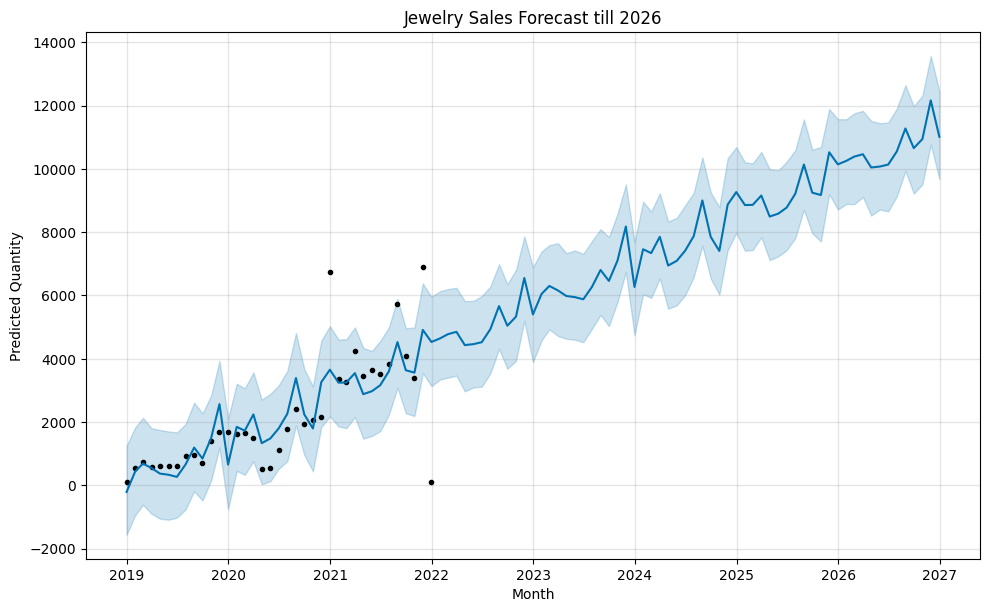


 Top Month in 2026:
            ds          yhat
95 2026-11-30  12162.796158

 Total Predicted Quantity in 2026: 127939
Estimated Revenue in 2026: ₹46341060.24

Forecast for Next Month:
            ds         yhat
87 2026-03-31  10461.15706


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:

!pip install prophet

import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt
from datetime import datetime


df = pd.read_csv("final_cleaned_jewelry_data.csv")
df['Datetime'] = pd.to_datetime(df['Datetime'], errors='coerce')
df = df.dropna(subset=['Datetime'])


monthly_sales = df.resample('M', on='Datetime')['Quantity'].sum().reset_index()
monthly_sales.rename(columns={'Datetime': 'ds', 'Quantity': 'y'}, inplace=True)
monthly_sales['ds'] = monthly_sales['ds'].dt.tz_localize(None)

model = Prophet()
model.fit(monthly_sales)

future = model.make_future_dataframe(periods=60,freq='M')
forecast = model.predict(future)

model.plot(forecast)
plt.title("Jewelry Sales Forecast till 2026")
plt.ylabel("Predicted Quantity")
plt.xlabel("Month")
plt.show()

forecast_2026 = forecast[forecast['ds'].dt.year == 2026]
top_month_2026 = forecast_2026.sort_values(by='yhat', ascending=False).head(1)
print("\n Top Month in 2026:\n", top_month_2026[['ds', 'yhat']])


total_qty_2026 = forecast_2026['yhat'].sum()
average_price = 362.21
total_revenue_2026 = total_qty_2026 * average_price
print(f"\n Total Predicted Quantity in 2026: {int(total_qty_2026)}")
print(f"Estimated Revenue in 2026: ₹{round(total_revenue_2026, 2)}")

today = datetime.today()
if today.month == 12:
    next_month = 1
    next_year = today.year + 1
else:
    next_month = today.month + 1
    next_year = today.year

next_month_forecast = forecast[(forecast['ds'].dt.month == next_month) & (forecast['ds'].dt.year == next_year)]
print("\nForecast for Next Month:\n", next_month_forecast[['ds', 'yhat']])

forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].to_csv('jewelry_forecast_2026.csv', index=False)
from google.colab import files
files.download('jewelry_forecast_2026.csv')


*Prophet Modal Accuracy*

In [ ]:

monthly_sales = df.resample('M', on='Datetime')['Quantity'].sum().reset_index()
monthly_sales.rename(columns={'Datetime': 'ds', 'Quantity': 'y'}, inplace=True)
monthly_sales['ds'] = monthly_sales['ds'].dt.tz_localize(None)


from prophet import Prophet
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.5,
    seasonality_prior_scale=10
)
model.add_seasonality(name='monthly', period=30.5, fourier_order=5)
model.fit(monthly_sales)


from prophet.diagnostics import cross_validation, performance_metrics

df_cv = cross_validation(model, initial='730 days', period='180 days', horizon='365 days')
df_p = performance_metrics(df_cv)
print("\n📊 Cross-Validation Performance (Average):")
print(df_p[['mae','rmse','mape']].mean())


/tmp/ipython-input-4155833372.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df.resample('M', on='Datetime')['Quantity'].sum().reset_index()
INFO:prophet:Making 1 forecasts with cutoffs between 2020-12-31 00:00:00 and 2020-12-31 00:00:00


  0%|          | 0/1 [00:00<?, ?it/s]

INFO:prophet:n_changepoints greater than number of observations. Using 19.



📊 Cross-Validation Performance (Average):
mae     7731.395159
rmse    7731.395159
mape      13.762590
dtype: float64


In [ ]:
from prophet.diagnostics import cross_validation, performance_metrics


df_cv = cross_validation(model, initial='730 days', period='180 days', horizon='365 days')
df_p = performance_metrics(df_cv)

mae = df_p['mae'].mean()
rmse = df_p['rmse'].mean()
mape = df_p['mape'].mean()

accuracy = 100 - mape

print("\n📊 Cross-Validation Performance (Average):")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")
print(f"✅ Accuracy: {accuracy:.2f}%")

INFO:prophet:Making 1 forecasts with cutoffs between 2020-12-31 00:00:00 and 2020-12-31 00:00:00


  0%|          | 0/1 [00:00<?, ?it/s]

INFO:prophet:n_changepoints greater than number of observations. Using 19.



📊 Cross-Validation Performance (Average):
MAE: 7731.40
RMSE: 7731.40
MAPE: 13.76%
✅ Accuracy: 86.24%
